# AdaBoost Classifier

AdaBoost is an ensemble learning method that combines multiple weak learners to build a stronger predictive model.

In this notebook, AdaBoost is implemented using decision trees as weak learners. The trees are trained sequentially, with greater attention being given to observations that were incorrectly classified by previous learners.

The model is evaluated using temporal cross-validation in order to respect the chronological nature of the tennis dataset. Different combinations of the number of estimators, learning rate, and maximum number of leaf nodes are tested to identify the best configuration. The selected model is then trained on the complete training period and evaluated on the 2023 validation set.

Finally, the notebook analyses the model's performance using several classification metrics and investigates feature importance to understand which characteristics of a match contribute most to the prediction.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import (
    validation_years,
    create_temporal_folds
)

from src.evaluation import (
    evaluate_model
)


from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
PROCESSED_DATA_DIR = Path(
    "../data/processed"
)

input_file = (
    PROCESSED_DATA_DIR
    /
    "feature_split_matches.csv"
)

matches = pd.read_csv(
    input_file,
    parse_dates=["Date"]
)

matches = matches.sort_values(
    by=[
        "Date",
        "MatchID"
    ]
).reset_index(
    drop=True
)

print(
    "Dataset shape:",
    matches.shape
)

print(
    matches[
        "DataSplit"
    ].value_counts()
)

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [3]:
train_data = matches.loc[
    matches["DataSplit"]
    ==
    "Training"
].copy()


validation_data = matches.loc[
    matches["DataSplit"]
    ==
    "Validation"
].copy()


test_data = matches.loc[
    matches["DataSplit"]
    ==
    "Test"
].copy()

print(
    "Training:",
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validation:",
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Test:",
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)

Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validation: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [4]:
assert (
    train_data["Date"].max()
    <
    validation_data["Date"].min()
)

assert (
    validation_data["Date"].max()
    <
    test_data["Date"].min()
)

print(
    "Chronological order is maintained."
)

Chronological order is maintained.


In [5]:
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw selected features:",
    len(numeric_features)
    +
    len(categorical_features)
)

Numerical features: 30
Categorical features: 5
Raw selected features: 35


In [6]:
temporal_folds = create_temporal_folds(
    train_data,
    validation_years
)

print(
    "Number of temporal folds:",
    len(temporal_folds)
)

pd.DataFrame(
    temporal_folds
)

Number of temporal folds: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


In [7]:
configurations = [

    {
        "name": "AdaBoost leaves 2 est 50 lr 0.1",
        "max_leaf_nodes": 2,
        "n_estimators": 50,
        "learning_rate": 0.1
    },

    {
        "name": "AdaBoost leaves 2 est 100 lr 0.1",
        "max_leaf_nodes": 2,
        "n_estimators": 100,
        "learning_rate": 0.1
    },

    {
        "name": "AdaBoost leaves 2 est 50 lr 0.5",
        "max_leaf_nodes": 2,
        "n_estimators": 50,
        "learning_rate": 0.5
    },

    {
        "name": "AdaBoost leaves 2 est 100 lr 0.5",
        "max_leaf_nodes": 2,
        "n_estimators": 100,
        "learning_rate": 0.5
    },

    {
        "name": "AdaBoost leaves 4 est 50 lr 0.1",
        "max_leaf_nodes": 4,
        "n_estimators": 50,
        "learning_rate": 0.1
    },

    {
        "name": "AdaBoost leaves 4 est 100 lr 0.1",
        "max_leaf_nodes": 4,
        "n_estimators": 100,
        "learning_rate": 0.1
    },

    {
        "name": "AdaBoost leaves 4 est 50 lr 0.5",
        "max_leaf_nodes": 4,
        "n_estimators": 50,
        "learning_rate": 0.5
    },

    {
        "name": "AdaBoost leaves 4 est 100 lr 0.5",
        "max_leaf_nodes": 4,
        "n_estimators": 100,
        "learning_rate": 0.5
    }
]

print(
    "Configurations:",
    len(configurations)
)

Configurations: 8


Since we have 8 configurations × 4 folds we will perform 32 experiments.

For AdaBoost we're going to tune three parameters:
- **max_leaf_nodes**: e.g. max_leaf_nodes = 2 means each decision tree is extremely simple. It basically makes one simple division of the data. These simple trees are usually called weak learners. This is intentional because the idea of AdaBoost is not to build one extremely intelligent tree but to combine many relatively simple trees.
- **n_estimators**: e.g. n_estimators = 100 means "create up to 100 weak decision trees". So n_estimators is the number of boosting rounds.
- **learning_rate**: controls how strongly each new weak learner contributes. Lower means more cautious learning, higher means each tree has more influence.

In [8]:
#Prepare result list: we'll store the result of every experiment here.

adaboost_cv_results = []


for configuration in configurations:

    print(
        "Testing:",
        configuration["name"]
    )


    for fold in temporal_folds:

        fold_number = (
            fold["Fold"]
        )

        validation_year = (
            fold["ValidationYear"]
        )


        #Use only previous years for training
        fold_train = train_data.loc[
            train_data["Date"].dt.year
            <
            validation_year
        ].copy()


        #Predict the next year
        fold_validation = train_data.loc[
            train_data["Date"].dt.year
            ==
            validation_year
        ].copy()


        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor(
            fold_train
        )


        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )


        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )


        y_fold_train = (
            fold_train[
                "Player1Won"
            ].to_numpy()
        )


        y_fold_validation = (
            fold_validation[
                "Player1Won"
            ].to_numpy()
        )


        #We intentionally create a relatively small decision tree
        weak_tree = DecisionTreeClassifier(

            max_leaf_nodes=configuration[
                "max_leaf_nodes"
            ],

            random_state=42
        )


        #We give that tree to AdaBoost:
        current_model = AdaBoostClassifier(

            estimator=weak_tree,

            n_estimators=configuration[
                "n_estimators"
            ],

            learning_rate=configuration[
                "learning_rate"
            ],

            random_state=42
        )


        current_model.fit(
            X_fold_train,
            y_fold_train
        )


        current_predictions = (
            current_model.predict(
                X_fold_validation
            )
        )


        current_probabilities = (
            current_model.predict_proba(
                X_fold_validation
            )[:, 1]
        )


        current_fold_results = (
            evaluate_model(

                y_true=y_fold_validation,

                y_pred=current_predictions,

                model_name=configuration[
                    "name"
                ],

                y_probability=current_probabilities
            )
        )


        current_fold_result = (
            current_fold_results
            .iloc[0]
            .to_dict()
        )


        current_fold_result[
            "Fold"
        ] = fold_number


        current_fold_result[
            "ValidationYear"
        ] = validation_year


        current_fold_result[
            "MaxLeafNodes"
        ] = configuration[
            "max_leaf_nodes"
        ]


        current_fold_result[
            "NEstimators"
        ] = configuration[
            "n_estimators"
        ]


        current_fold_result[
            "LearningRate"
        ] = configuration[
            "learning_rate"
        ]


        adaboost_cv_results.append(
            current_fold_result
        )


        print(
            "  Fold",
            fold_number,
            "-",
            validation_year,
            "- Accuracy:",
            round(
                current_fold_result[
                    "Accuracy"
                ],
                4
            )
        )

Testing: AdaBoost leaves 2 est 50 lr 0.1
  Fold 1 - 2019 - Accuracy: 0.6296
  Fold 2 - 2020 - Accuracy: 0.6377
  Fold 3 - 2021 - Accuracy: 0.6382
  Fold 4 - 2022 - Accuracy: 0.6479
Testing: AdaBoost leaves 2 est 100 lr 0.1
  Fold 1 - 2019 - Accuracy: 0.6292
  Fold 2 - 2020 - Accuracy: 0.6353
  Fold 3 - 2021 - Accuracy: 0.6366
  Fold 4 - 2022 - Accuracy: 0.6487
Testing: AdaBoost leaves 2 est 50 lr 0.5
  Fold 1 - 2019 - Accuracy: 0.6175
  Fold 2 - 2020 - Accuracy: 0.6466
  Fold 3 - 2021 - Accuracy: 0.6324
  Fold 4 - 2022 - Accuracy: 0.6464
Testing: AdaBoost leaves 2 est 100 lr 0.5
  Fold 1 - 2019 - Accuracy: 0.6183
  Fold 2 - 2020 - Accuracy: 0.6474
  Fold 3 - 2021 - Accuracy: 0.6332
  Fold 4 - 2022 - Accuracy: 0.6472
Testing: AdaBoost leaves 4 est 50 lr 0.1
  Fold 1 - 2019 - Accuracy: 0.6364
  Fold 2 - 2020 - Accuracy: 0.6336
  Fold 3 - 2021 - Accuracy: 0.6357
  Fold 4 - 2022 - Accuracy: 0.6487
Testing: AdaBoost leaves 4 est 100 lr 0.1
  Fold 1 - 2019 - Accuracy: 0.636
  Fold 2 - 2020 -

In [9]:
#Convert CV results to DataFrame

adaboost_cv_fold_results = pd.DataFrame(
    adaboost_cv_results
)

adaboost_cv_fold_results

print(
    "Number of CV experiments:",
    len(
        adaboost_cv_fold_results
    )
)

assert (
    len(adaboost_cv_fold_results)
    ==
    len(configurations)
    *
    len(temporal_folds)
)

print(
    "AdaBoost CV experiment count correct."
)

Number of CV experiments: 32
AdaBoost CV experiment count correct.


In [10]:
#Calculate average CV performance

adaboost_cv_summary = (

    adaboost_cv_fold_results.groupby(

        [
            "Model",
            "MaxLeafNodes",
            "NEstimators",
            "LearningRate"
        ],

        as_index=False

    ).agg(

        MeanAccuracy=(
            "Accuracy",
            "mean"
        ),

        StdAccuracy=(
            "Accuracy",
            "std"
        ),

        MeanBalancedAccuracy=(
            "BalancedAccuracy",
            "mean"
        ),

        MeanF1Score=(
            "F1",
            "mean"
        ),

        MeanROC_AUC=(
            "ROC-AUC",
            "mean"
        ),

        MeanLogLoss=(
            "LogLoss",
            "mean"
        )
    )
)


#Sort:
adaboost_cv_summary = (

    adaboost_cv_summary.sort_values(

        by=[
            "MeanAccuracy",
            "MeanROC_AUC"
        ],

        ascending=[
            False,
            False
        ]

    ).reset_index(
        drop=True
    )
)

adaboost_cv_summary

,Model,MaxLeafNodes,NEstimators,LearningRate,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,AdaBoost leaves 4 est 100 lr 0.5,4,100,0.5,0.642794,0.011229,0.642965,0.636830,0.697564,0.632174
1,AdaBoost leaves 4 est 100 lr 0.1,4,100,0.1,0.639222,0.006617,0.639226,0.629263,0.697314,0.634321
2,AdaBoost leaves 4 est 50 lr 0.1,4,50,0.1,0.638610,0.006842,0.638405,0.625462,0.695934,0.647534
3,AdaBoost leaves 2 est 50 lr 0.1,2,50,0.1,0.638351,0.007521,0.638129,0.625734,0.694400,0.647278
4,AdaBoost leaves 4 est 50 lr 0.5,4,50,0.5,0.637879,0.011124,0.638114,0.631270,0.696085,0.631125
5,AdaBoost leaves 2 est 100 lr 0.1,2,100,0.1,0.637422,0.008196,0.637292,0.626124,0.695365,0.636511
6,AdaBoost leaves 2 est 100 lr 0.5,2,100,0.5,0.636539,0.013828,0.636312,0.625356,0.694739,0.633123
7,AdaBoost leaves 2 est 50 lr 0.5,2,50,0.5,0.635731,0.013831,0.635537,0.625383,0.693398,0.632938


The first row is now our preferred AdaBoost configuration.

We use mean accuracy because one particular year might just be easier or harder to predict.

For example:

Model A:

2019 → 0.65
2020 → 0.63
2021 → 0.64
2022 → 0.63

Model B:

2019 → 0.70
2020 → 0.57
2021 → 0.61
2022 → 0.59

Model A is probably more trustworthy than Model B even though Model B was fantastic once.
That's also why we're storing StdAccuracy.

In [11]:
#Select best configuration

best_model_name = (
    adaboost_cv_summary
    .iloc[0][
        "Model"
    ]
)

print(
    "Selected AdaBoost:",
    best_model_name
)

#Recover the dictionary:
best_configuration = next(

    configuration

    for configuration
    in configurations

    if configuration["name"]
    ==
    best_model_name
)

best_configuration

Selected AdaBoost: AdaBoost leaves 4 est 100 lr 0.5


{'name': 'AdaBoost leaves 4 est 100 lr 0.5',
 'max_leaf_nodes': 4,
 'n_estimators': 100,
 'learning_rate': 0.5}

In [12]:
#Fit preprocessing on all 2015-2022 data

#We can use all training data
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

#Transform training:
X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

#Transform 2023 validation:
X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

#Targets:
y_train = (
    train_data[
        "Player1Won"
    ].to_numpy()
)

y_validation = (
    validation_data[
        "Player1Won"
    ].to_numpy()
)


print(
    "Training X:",
    X_train.shape
)

print(
    "Validation X:",
    X_validation.shape
)

print(
    "Training y:",
    y_train.shape
)

print(
    "Validation y:",
    y_validation.shape
)


assert (
    X_train.isna()
    .sum()
    .sum()
    ==
    0
)

assert (
    X_validation.isna()
    .sum()
    .sum()
    ==
    0
)

print(
    "AdaBoost preprocessing check passed."
)


assert (
    X_train.shape[1]
    ==
    X_validation.shape[1]
)

Training X: (18810, 50)
Validation X: (2607, 50)
Training y: (18810,)
Validation y: (2607,)
AdaBoost preprocessing check passed.


In [13]:
#Create the selected weak tree
best_weak_tree = DecisionTreeClassifier(

    max_leaf_nodes=best_configuration[
        "max_leaf_nodes"
    ],

    random_state=42
)

We haven't trained it directly. We're going to give it to AdaBoost.

In [14]:
#Create best AdaBoost model
best_adaboost = AdaBoostClassifier(

    estimator=best_weak_tree,

    n_estimators=best_configuration[
        "n_estimators"
    ],

    learning_rate=best_configuration[
        "learning_rate"
    ],

    random_state=42
)

In [15]:
#Train on all 2015–2022
best_adaboost.fit(
    X_train,
    y_train
)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.35,0.41,0.43,...,0.5 ,0.5 ,0.5 ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[0.31,0.18,0.15,...,0. ,0. ,0. ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](50,)","[0. ,0. ,0.04,...,0. ,0. ,0. ]"


Now the selected model is trained using all development-training data.

In [16]:
#Predict 2023

#Classes:
best_validation_predictions = (
    best_adaboost.predict(
        X_validation
    )
)

#Probabilities:
best_validation_probabilities = (
    best_adaboost.predict_proba(
        X_validation
    )[:, 1] #probability that Player 1 wins
)

In [17]:
#Classification report
print(
    classification_report(

        y_validation,

        best_validation_predictions,

        target_names=[
            "Player 2 wins",
            "Player 1 wins"
        ],

        zero_division=0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.66      0.63      0.65      1368
Player 1 wins       0.61      0.64      0.62      1239

     accuracy                           0.63      2607
    macro avg       0.63      0.63      0.63      2607
 weighted avg       0.64      0.63      0.64      2607



In [18]:
#Main evaluation metrics
best_adaboost_result = evaluate_model(

    y_true=y_validation,

    y_pred=(
        best_validation_predictions
    ),

    model_name=(
        best_model_name
    ),

    y_probability=(
        best_validation_probabilities
    )
)

best_adaboost_result

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,AdaBoost leaves 4 est 100 lr 0.5,0.634829,0.634922,0.611154,0.636804,0.623715,0.698723,0.631597


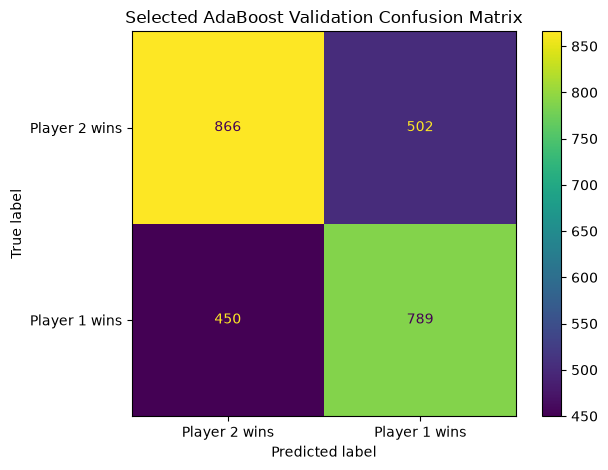

In [19]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(

    y_validation,

    best_validation_predictions,

    display_labels=[
        "Player 2 wins",
        "Player 1 wins"
    ],

    values_format="d"
)

plt.title(
    "Selected AdaBoost Validation Confusion Matrix"
)

plt.tight_layout()

plt.show()

In [20]:
#AdaBoost feature importance

#We create a DataFrame
adaboost_feature_importance = pd.DataFrame(
    {
        "Feature":
            X_train.columns,

        "Importance":
            best_adaboost.feature_importances_
    }
)

#Sort it:
adaboost_feature_importance = (

    adaboost_feature_importance.sort_values(

        by="Importance",

        ascending=False

    ).reset_index(
        drop=True
    )
)

adaboost_feature_importance

,Feature,Importance
0,PointsDifference,0.518056
1,WinRateDifference,0.088530
2,SurfaceWinRateDifference,0.084506
3,Player1WinRateBefore,0.048445
4,Player1Points,0.038037
5,RankDifference,0.037455
6,Recent5WinRateDifference,0.028922
7,Player2MatchesBefore,0.021236
8,Player2WinRateBefore,0.019297
9,Player2SurfaceMatchesBefore,0.017197


In [21]:
#Check feature importance
print(
    "Number of model features:",
    X_train.shape[1]
)

print(
    "Number of importance values:",
    len(
        best_adaboost.feature_importances_
    )
)

assert (
    len(
        adaboost_feature_importance
    )
    ==
    X_train.shape[1]
)

print(
    "Feature importance check passed."
)

Number of model features: 50
Number of importance values: 50
Feature importance check passed.


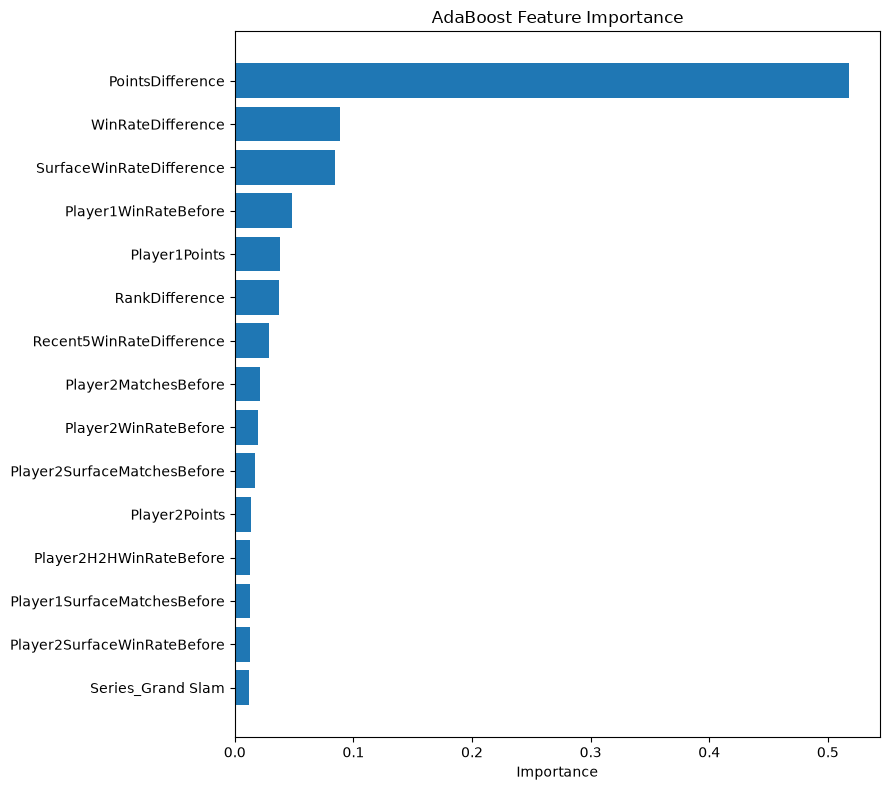

In [22]:
#Show top 15 features
top_features = (

    adaboost_feature_importance
    .head(15)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

#Plot:
plt.figure(
    figsize=(9, 8)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.title(
    "AdaBoost Feature Importance"
)

plt.tight_layout()

plt.show()

In [23]:
#Show the top features numerically

print(
    "Top 15 AdaBoost features:"
)

print(
    adaboost_feature_importance.head(
        15
    )
)

Top 15 AdaBoost features:
                        Feature  Importance
0              PointsDifference    0.518056
1             WinRateDifference    0.088530
2      SurfaceWinRateDifference    0.084506
3          Player1WinRateBefore    0.048445
4                 Player1Points    0.038037
5                RankDifference    0.037455
6      Recent5WinRateDifference    0.028922
7          Player2MatchesBefore    0.021236
8          Player2WinRateBefore    0.019297
9   Player2SurfaceMatchesBefore    0.017197
10                Player2Points    0.013468
11      Player2H2HWinRateBefore    0.013184
12  Player1SurfaceMatchesBefore    0.012824
13  Player2SurfaceWinRateBefore    0.012786
14            Series_Grand Slam    0.011672


In [24]:
#Analyze tuning results
adaboost_cv_summary[
    [
        "MaxLeafNodes",
        "NEstimators",
        "LearningRate",
        "MeanAccuracy",
        "StdAccuracy",
        "MeanROC_AUC",
        "MeanLogLoss"
    ]
]

,MaxLeafNodes,NEstimators,LearningRate,MeanAccuracy,StdAccuracy,MeanROC_AUC,MeanLogLoss
0,4,100,0.5,0.642794,0.011229,0.697564,0.632174
1,4,100,0.1,0.639222,0.006617,0.697314,0.634321
2,4,50,0.1,0.638610,0.006842,0.695934,0.647534
3,2,50,0.1,0.638351,0.007521,0.694400,0.647278
4,4,50,0.5,0.637879,0.011124,0.696085,0.631125
5,2,100,0.1,0.637422,0.008196,0.695365,0.636511
6,2,100,0.5,0.636539,0.013828,0.694739,0.633123
7,2,50,0.5,0.635731,0.013831,0.693398,0.632938


We make a simple graph showing mean accuracy for every configuration.

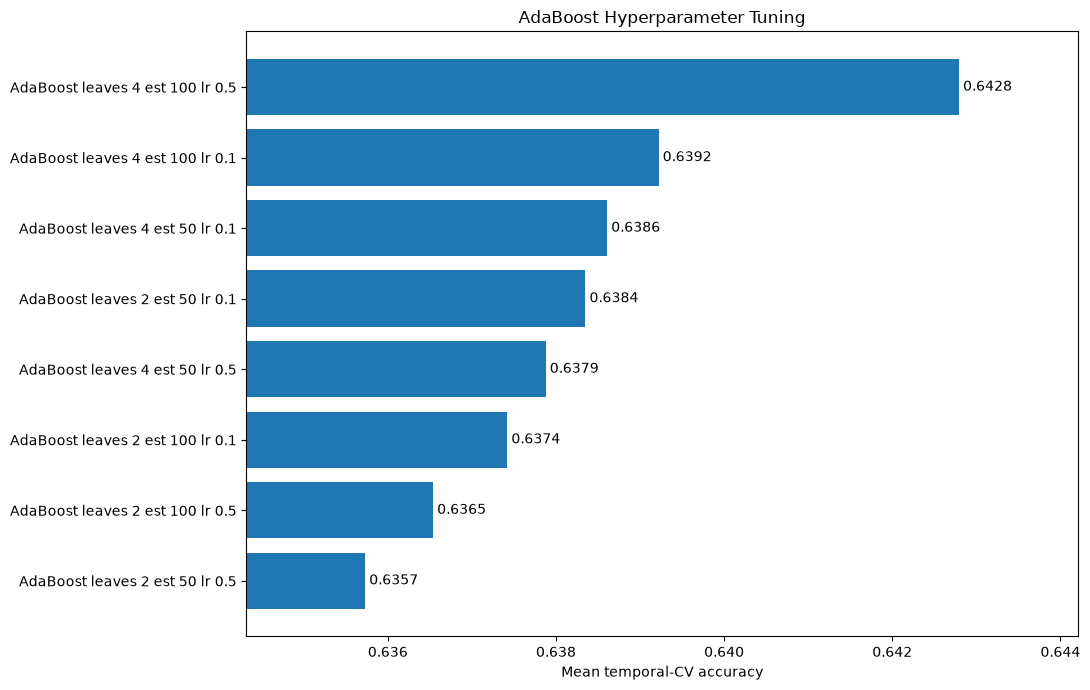

In [25]:
plot_data = (
    adaboost_cv_summary
    .sort_values(
        "MeanAccuracy",
        ascending=True
    )
)

min_accuracy = plot_data["MeanAccuracy"].min()
max_accuracy = plot_data["MeanAccuracy"].max()

difference = max_accuracy - min_accuracy

padding = max(
    difference * 0.20,
    0.001
)

plt.figure(
    figsize=(11, 7)
)

bars = plt.barh(
    plot_data["Model"],
    plot_data["MeanAccuracy"]
)

plt.xlim(
    min_accuracy - padding,
    max_accuracy + padding
)

plt.xlabel(
    "Mean temporal-CV accuracy"
)

plt.title(
    "AdaBoost Hyperparameter Tuning"
)

for bar, value in zip (
    bars,
    plot_data["MeanAccuracy"]
):
    plt.text(
        value,
        bar.get_y()
        + bar.get_height() / 2,

        f" {value:.4f}",

        va = "center"
    )

plt.tight_layout()

plt.show()

In [26]:
#Create output directories
MODEL_SELECTION_RESULTS_DIR = Path(
    "../results/model_selection"
)

VALIDATION_RESULTS_DIR = Path(
    "../results/validation"
)

FEATURE_IMPORTANCE_RESULTS_DIR = Path(
    "../results/feature_importance"
)

MODELS_DIR = Path("../models")

In [27]:
#Save tuning results
adaboost_cv_fold_results.to_csv(
    MODEL_SELECTION_RESULTS_DIR
    / "adaboost_cv_fold_results.csv",
    index=False
)

adaboost_cv_summary.to_csv(
    MODEL_SELECTION_RESULTS_DIR
    /"adaboost_cv_tuning_summary.csv",
    index=False
)

#Save validation result:
best_adaboost_result.to_csv(
    VALIDATION_RESULTS_DIR 
    /"best_adaboost_result.csv",
    index=False
)

#Save feature importance
adaboost_feature_importance.to_csv(
    FEATURE_IMPORTANCE_RESULTS_DIR 
    /"adaboost_feature_importance.csv",
    index=False
)

In [28]:
#Save the model
import joblib

joblib.dump(
    best_adaboost,
    MODELS_DIR
    / "best_adaboost_validation.joblib"
)

['..\\models\\best_adaboost_validation.joblib']

Save preprocessing too.
Unlike k-NN, AdaBoost doesn't have a scaler, but it still depends on the preprocessing objects.

In [29]:
adaboost_preprocessing = {
    "numeric_medians": numeric_medians,
    "categorical_modes":  categorical_modes,
    "one_hot_encoder":  one_hot_encoder
}

joblib.dump(
    adaboost_preprocessing,
    MODELS_DIR
    /"adaboost_preprocessing.joblib"
)

['..\\models\\adaboost_preprocessing.joblib']

This means that later we can reproduce exactly the same transformation.

In [30]:
#Final summary

print("ADABOOST TEMPORAL CV")
print( adaboost_cv_summary)

print("\nSelected configuration:")
print(best_configuration)

print("\nExternal 2023 validation:")
print( best_adaboost_result)

print("\nTop 15 features:")

print(adaboost_feature_importance.head(15))

ADABOOST TEMPORAL CV
                              Model  MaxLeafNodes  NEstimators  LearningRate  \
0  AdaBoost leaves 4 est 100 lr 0.5             4          100           0.5   
1  AdaBoost leaves 4 est 100 lr 0.1             4          100           0.1   
2   AdaBoost leaves 4 est 50 lr 0.1             4           50           0.1   
3   AdaBoost leaves 2 est 50 lr 0.1             2           50           0.1   
4   AdaBoost leaves 4 est 50 lr 0.5             4           50           0.5   
5  AdaBoost leaves 2 est 100 lr 0.1             2          100           0.1   
6  AdaBoost leaves 2 est 100 lr 0.5             2          100           0.5   
7   AdaBoost leaves 2 est 50 lr 0.5             2           50           0.5   

   MeanAccuracy  StdAccuracy  MeanBalancedAccuracy  MeanF1Score  MeanROC_AUC  \
0      0.642794     0.011229              0.642965     0.636830     0.697564   
1      0.639222     0.006617              0.639226     0.629263     0.697314   
2      0.638610   